In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import silhouette_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import silhouette_score
import seaborn as sns
import xgboost as xgb
import joblib


In [ ]:
df = pd.read_csv("heart_2020.csv")
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [ ]:
print("Shape of dataset:", df.shape)

df.info()

print(df.dtypes)

Shape of dataset: (252936, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252936 entries, 0 to 252935
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      252936 non-null  object 
 1   BMI               252936 non-null  float64
 2   Smoking           252936 non-null  object 
 3   AlcoholDrinking   252936 non-null  object 
 4   Stroke            252936 non-null  object 
 5   PhysicalHealth    252935 non-null  float64
 6   MentalHealth      252935 non-null  float64
 7   DiffWalking       252935 non-null  object 
 8   Sex               252935 non-null  object 
 9   AgeCategory       252935 non-null  object 
 10  Race              252935 non-null  object 
 11  Diabetic          252935 non-null  object 
 12  PhysicalActivity  252935 non-null  object 
 13  GenHealth         252935 non-null  object 
 14  SleepTime         252935 non-null  float64
 15  Asthma            252935 non-null  ob

In [ ]:
df.shape

(252936, 18)

In [ ]:
df.columns

Index(['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke',
       'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory',
       'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime',
       'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object')

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
252931,False
252932,False
252933,True
252934,False


In [ ]:
df.isnull().sum()

,0
HeartDisease,0
BMI,0
Smoking,0
AlcoholDrinking,0
Stroke,0
PhysicalHealth,1
MentalHealth,1
DiffWalking,1
Sex,1
AgeCategory,1


In [ ]:
num_col = 'SleepTime'
sleep_median = df[num_col].median()
df[num_col] = df[num_col].fillna(sleep_median)
print(f"Filled missing {num_col} with median: {sleep_median}")

Filled missing SleepTime with median: 7.0


In [ ]:
cat_cols = ['Asthma', 'KidneyDisease', 'SkinCancer']
for col in cat_cols:
    col_mode = df[col].mode()[0]
    df[col] = df[col].fillna(col_mode)
    print(f"Filled missing {col} with mode: {col_mode}")

Filled missing Asthma with mode: No
Filled missing KidneyDisease with mode: No
Filled missing SkinCancer with mode: No


In [ ]:
df['PhysicalActivity'] = df['PhysicalActivity'].fillna(df['PhysicalActivity'].mode()[0])
df['Race']= df['Race'].fillna(df['Race'].mode()[0])
df['Diabetic']= df['Diabetic'].fillna(df['Diabetic'].mode()[0])
df['GenHealth']= df['GenHealth'].fillna(df['GenHealth'].mode()[0])

In [ ]:
df.isnull().sum()

,0
HeartDisease,0
BMI,0
Smoking,0
AlcoholDrinking,0
Stroke,0
PhysicalHealth,1
MentalHealth,1
DiffWalking,1
Sex,1
AgeCategory,1


In [ ]:
df.duplicated().sum()

np.int64(12284)

In [ ]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

# ENCODING


In [ ]:
yes_no_dict = {
    'Yes': 1,
    'No': 0
}

for colname in ['HeartDisease', 'Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking',
                'PhysicalActivity', 'Asthma', 'KidneyDisease', 'SkinCancer']:
    df[colname] = df[colname].replace(yes_no_dict)


/tmp/ipython-input-3818253317.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[colname] = df[colname].replace(yes_no_dict)


In [ ]:
f_m_dict = {
    'Male': 1,
    'Female': 0
}

for colname in ['Sex']:
    # Fill missing values with the mode before replacement and type conversion
    df[colname] = df[colname].fillna(df[colname].mode()[0])
    df[colname] = df[colname].replace(f_m_dict).astype(int)


/tmp/ipython-input-649147950.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[colname] = df[colname].replace(f_m_dict).astype(int)


In [ ]:
age_dict = {
    '18-24': 1,
    '25-29': 2,
    '30-34': 3,
    '35-39': 4,
    '40-44': 5,
    '45-49': 6,
    '50-54': 7,
    '55-59': 8,
    '60-64': 9,
    '65-69': 10,
    '70-74': 11,
    '75-79': 12,
    '80 or older': 13
}

for colname in ['AgeCategory']:
    df[colname] = df[colname].replace(age_dict)


/tmp/ipython-input-1301521090.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[colname] = df[colname].replace(age_dict)


In [ ]:
gen_dict = {
    'Poor': 1,
    'Fair': 2,
    'Good': 3,
    'Very good': 4,
    'Excellent': 5
}

for colname in ['GenHealth']:
    df[colname] = df[colname].replace(gen_dict)


/tmp/ipython-input-334235830.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[colname] = df[colname].replace(gen_dict)


In [ ]:
onehot_columns = ['Race', 'Diabetic']
df= pd.get_dummies(df, columns = onehot_columns)

In [ ]:
df.head()


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,...,Race_American Indian/Alaskan Native,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,Diabetic_No,"Diabetic_No, borderline diabetes",Diabetic_Yes,Diabetic_Yes (during pregnancy)
0,0,16.60,1,0,0,3.0,30.0,0,0,8,...,False,False,False,False,False,True,False,False,True,False
1,0,20.34,0,0,1,0.0,0.0,0,0,13,...,False,False,False,False,False,True,True,False,False,False
2,0,26.58,1,0,0,20.0,30.0,0,1,10,...,False,False,False,False,False,True,False,False,True,False
3,0,24.21,0,0,0,0.0,0.0,0,0,12,...,False,False,False,False,False,True,True,False,False,False
4,0,23.71,0,0,0,28.0,0.0,1,0,5,...,False,False,False,False,False,True,True,False,False,False


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
HeartDisease,0
BMI,0
Smoking,0
AlcoholDrinking,0
Stroke,0
PhysicalHealth,0
MentalHealth,0
DiffWalking,0
Sex,0
AgeCategory,0


# **Outliers**

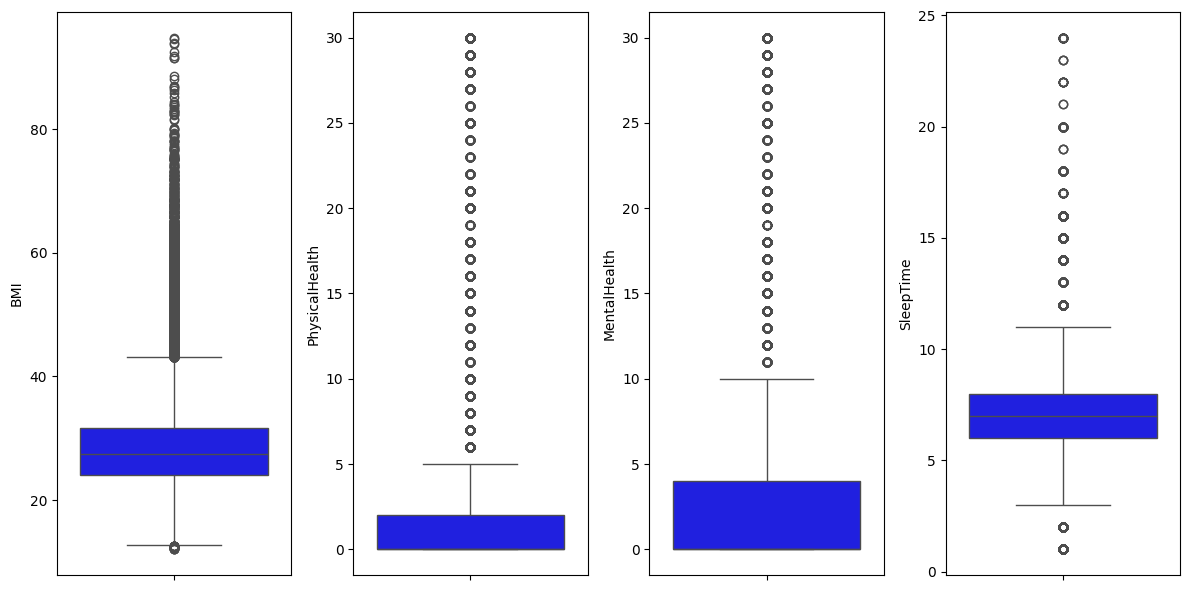

In [ ]:
plt.figure(figsize=(12,6))
numericals = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']
for i in range(0, len(numericals)):
    plt.subplot(1, len(numericals), i+1)
    sns.boxplot(y=df[numericals[i]], color='blue')
    plt.tight_layout()
plt.show()

In [ ]:
df.to_csv('heart_data_cleaned.csv', index=False)

# **Distribution**


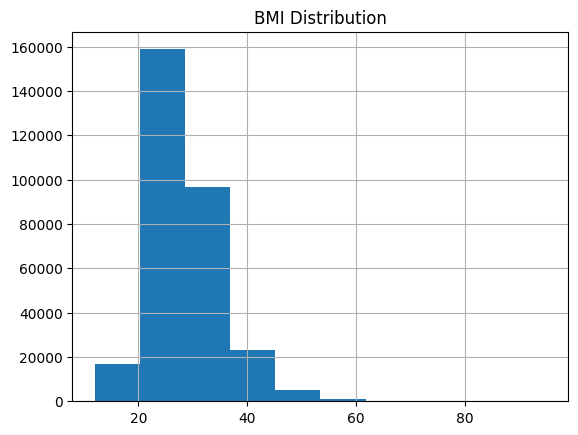

In [ ]:
df['BMI'].hist()
plt.title("BMI Distribution")
plt.show()

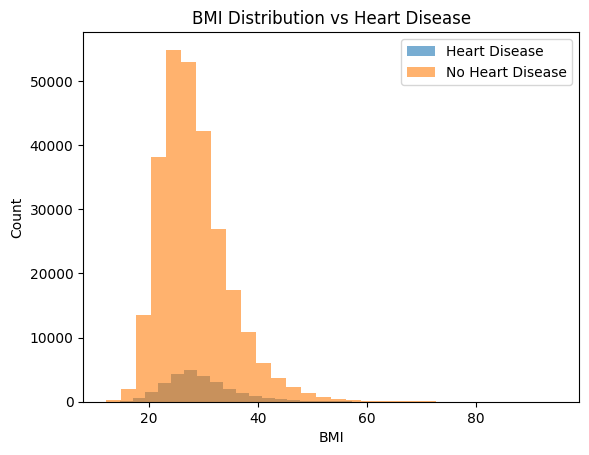

In [ ]:
# BMI distribution for Heart Disease = Yes
plt.hist(df[df['HeartDisease'] == 1]['BMI'], bins=30, alpha=0.6, label='Heart Disease')

# BMI distribution for Heart Disease = No
plt.hist(df[df['HeartDisease'] == 0]['BMI'], bins=30, alpha=0.6, label='No Heart Disease')

plt.xlabel('BMI')
plt.ylabel('Count')
plt.title('BMI Distribution vs Heart Disease')
plt.legend()
plt.show()

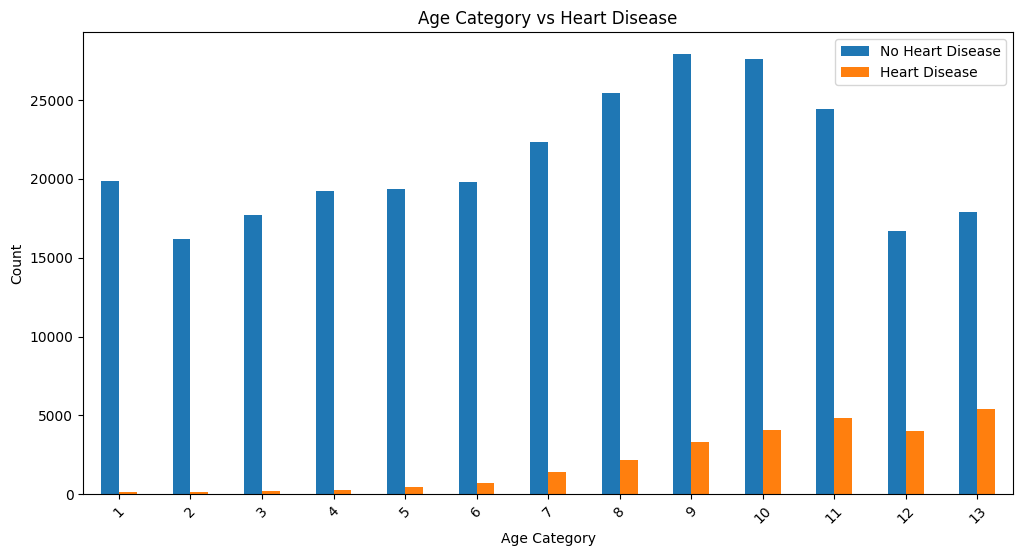

In [ ]:
age_hd = pd.crosstab(df['AgeCategory'], df['HeartDisease'])

age_hd.plot(kind='bar', figsize=(12,6))
plt.xlabel('Age Category')
plt.ylabel('Count')
plt.title('Age Category vs Heart Disease')
plt.legend(['No Heart Disease', 'Heart Disease'])
plt.xticks(rotation=45)
plt.show()

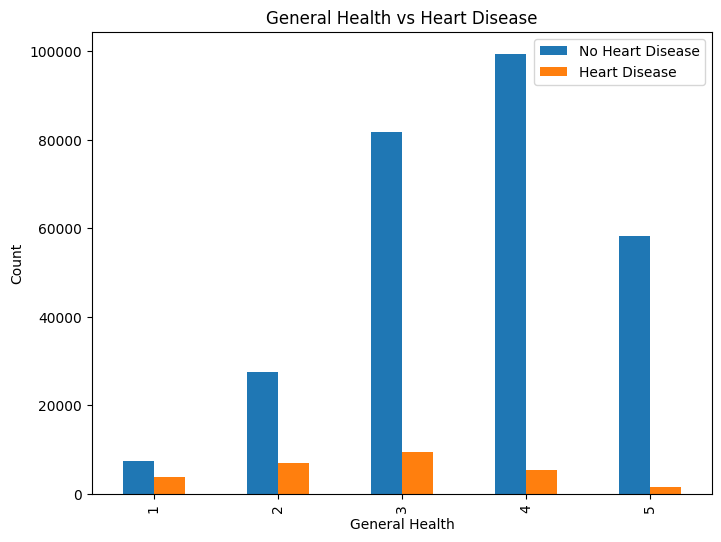

In [ ]:
gen_hd = pd.crosstab(df['GenHealth'], df['HeartDisease'])

gen_hd.plot(kind='bar', figsize=(8,6))
plt.xlabel('General Health')
plt.ylabel('Count')
plt.title('General Health vs Heart Disease')
plt.legend(['No Heart Disease', 'Heart Disease'])
plt.show()


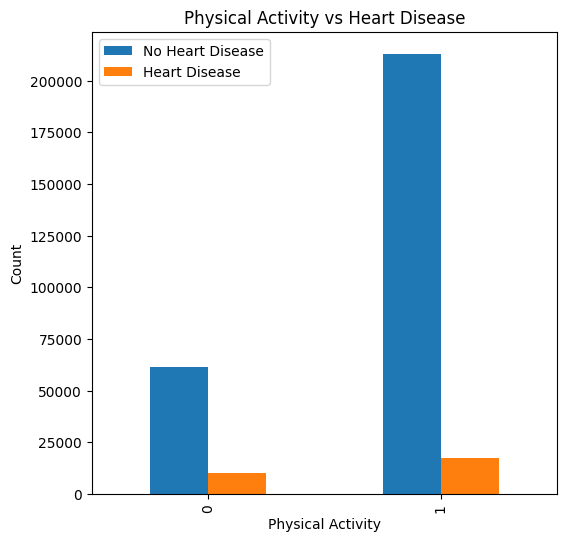

In [ ]:
pa_hd = pd.crosstab(df['PhysicalActivity'], df['HeartDisease'])

pa_hd.plot(kind='bar', figsize=(6,6))
plt.xlabel('Physical Activity')
plt.ylabel('Count')
plt.title('Physical Activity vs Heart Disease')
plt.legend(['No Heart Disease', 'Heart Disease'])
plt.show()


# **Correlation**

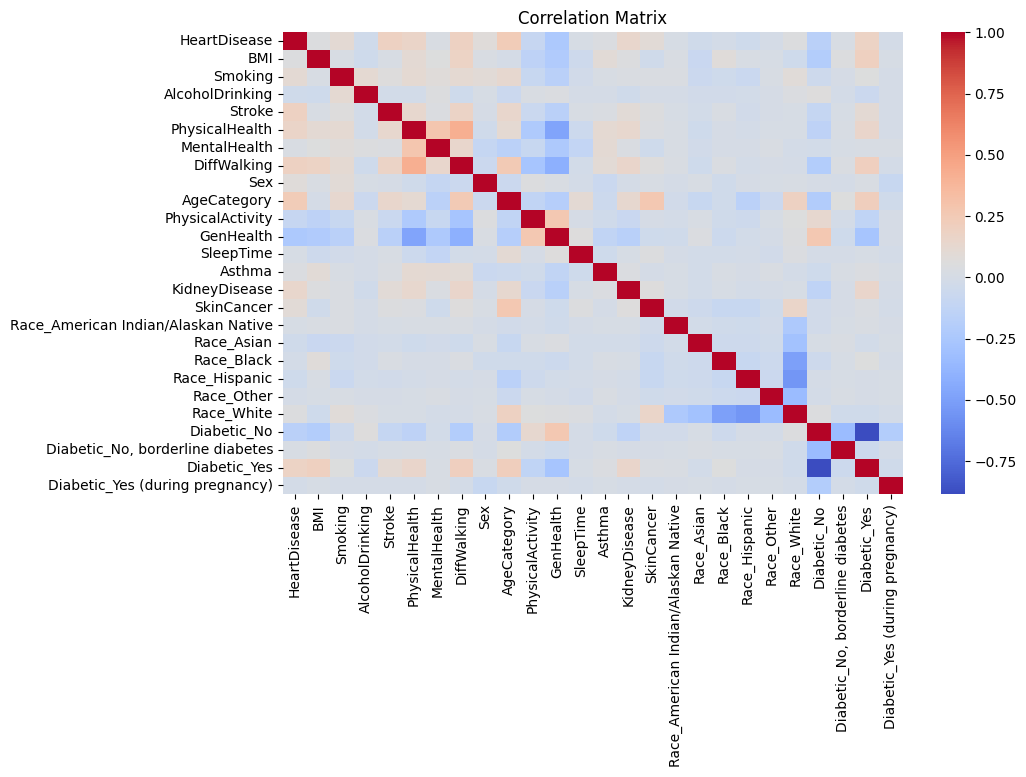

In [ ]:
plt.figure(figsize=(10,6))

# Fix: Convert boolean columns to integer (1 and 0) if any exist
# This ensures all columns are numeric for correlation calculation
boolean_cols = df.select_dtypes(include='bool').columns
if not boolean_cols.empty:
    for col in boolean_cols:
        df[col] = df[col].astype(int)

sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

/tmp/ipython-input-3298204544.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(X.values, labels=X.columns)


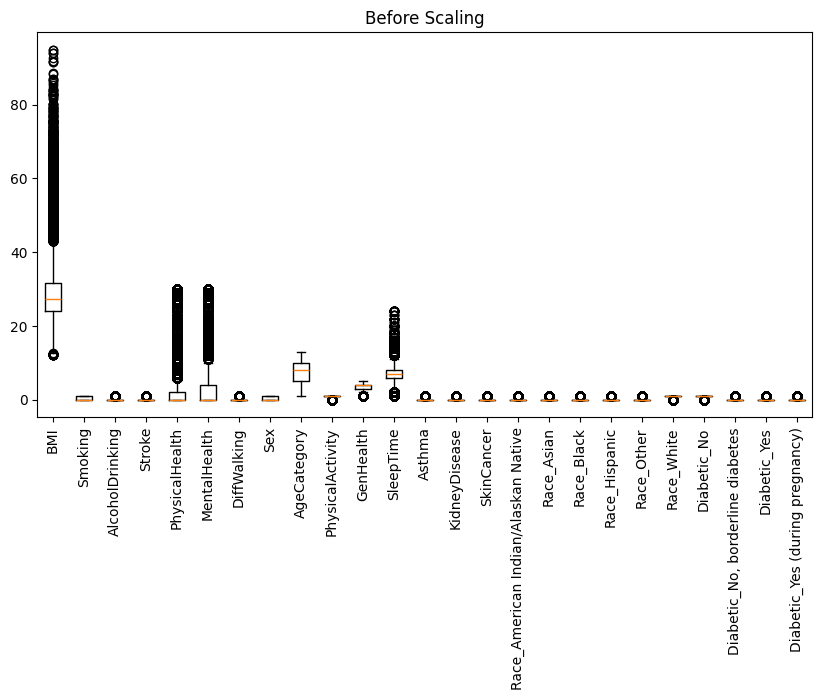

In [ ]:
plt.figure(figsize=(10,5))
plt.boxplot(X.values, labels=X.columns)
plt.title("Before Scaling")
plt.xticks(rotation=90)
plt.show()

# **StandardScaler**

In [ ]:
selected_features = [
    'GenHealth',
    'DiffWalking',
    'PhysicalHealth',
    'AgeCategory',
    'Stroke',
    'Smoking',
    'Diabetic_Yes',
    'Sex',
    'BMI',
    'PhysicalActivity'
]

X = df[selected_features]
y = df['HeartDisease']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

/tmp/ipython-input-1562755414.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(X_scaled, labels=X.columns)


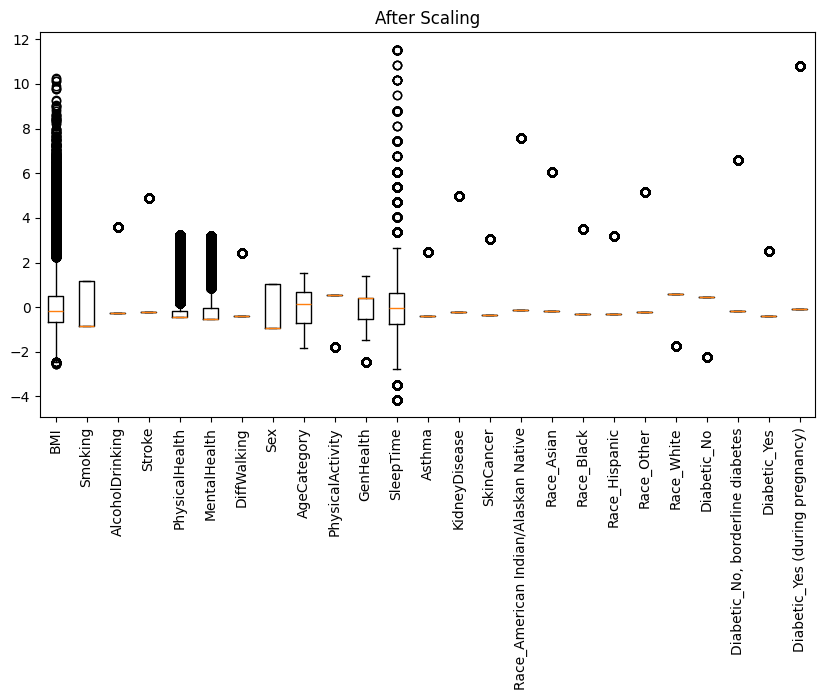

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(10,5))
plt.boxplot(X_scaled, labels=X.columns)
plt.title("After Scaling")
plt.xticks(rotation=90)
plt.show()


# **Target و Features للـ Regression**

In [ ]:
y_reg = df['BMI']

X_reg = df.drop(['BMI', 'HeartDisease'], axis=1)


In [ ]:
# تعويض القيم الناقصة بمتوسط كل عمود
X_reg = X_reg.fillna(X_reg.mean())


# تدريب Linear **Regression**

In [ ]:
# Train the Linear Regression model
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train_reg, y_train_reg)

LinearRegression()

# **Predictions**

In [ ]:
y_pred_reg = lin_reg_model.predict(X_test_reg)


# **Regression Metrics**

In [ ]:
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("Regression Metrics:")
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)



Regression Metrics:
MSE: 37.28503961926289
RMSE: 6.106147690587158
R² Score: 0.10667930509316847


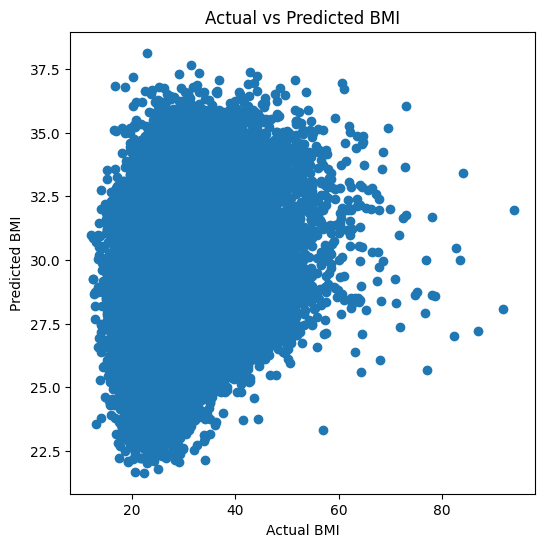

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_reg, y_pred_reg)
plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")
plt.title("Actual vs Predicted BMI")
plt.show()


LogisticRegression

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score
import matplotlib.pyplot as plt
# Load dataset
df = pd.read_csv("/content/heart_data_cleaned.csv")

y = df["HeartDisease"]

print("Samples:", x.shape[0])
print("Features:", x.shape[1])
y = y.map({'No': 0, 'Yes': 1})
print("Target classes:", y.unique())

Samples: 301717
Features: 25
Target classes: [nan]


In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler

# Load the dataset
df = pd.read_csv("/content/heart_data_cleaned.csv")

# Impute remaining missing values
df['MentalHealth'] = df['MentalHealth'].fillna(df['MentalHealth'].median())
df['DiffWalking'] = df['DiffWalking'].fillna(df['DiffWalking'].mode()[0])
df['AgeCategory'] = df['AgeCategory'].fillna(df['AgeCategory'].mode()[0])

# Features and Target
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

print(df.head())

# Convert categorical features to numerical
X = pd.get_dummies(X, drop_first=True)


   HeartDisease    BMI  Smoking  AlcoholDrinking  Stroke  PhysicalHealth  \
0             0  16.60        1                0       0             3.0   
1             0  20.34        0                0       1             0.0   
2             0  26.58        1                0       0            20.0   
3             0  24.21        0                0       0             0.0   
4             0  23.71        0                0       0            28.0   

   MentalHealth  DiffWalking  Sex  AgeCategory  ...  \
0          30.0            0    0            8  ...   
1           0.0            0    0           13  ...   
2          30.0            0    1           10  ...   
3           0.0            0    0           12  ...   
4           0.0            1    0            5  ...   

   Race_American Indian/Alaskan Native  Race_Asian  Race_Black  Race_Hispanic  \
0                                False       False       False          False   
1                                False       False

In [ ]:
# Create and train logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# Make predictions
y_pred_lr = model.predict(X_test)
y_proba_lr = model.predict_proba(X_test)
print(y_proba_lr[:5])

[[0.91297642 0.08702358]
 [0.98911663 0.01088337]
 [0.99537399 0.00462601]
 [0.98451978 0.01548022]
 [0.5519114  0.4480886 ]]


In [ ]:
# Make predictions for Logistic Regression within this cell to ensure variables are defined
y_pred_lr = model.predict(X_test)
y_proba_lr = model.predict_proba(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_lr)
cm = confusion_matrix(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr, pos_label=1)
recall = recall_score(y_test, y_pred_lr, pos_label=1)
f1_score_lr = f1_score(y_test, y_pred_lr, pos_label=1)
roc_auc_score_lr = roc_auc_score(y_test, y_proba_lr[:, 1])

print("Classification Results:")

print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(cm)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score_lr)
print("ROC AUC Score:", roc_auc_score_lr)


Classification Results:
Accuracy: 0.9107
Confusion Matrix:
[[54422   470]
 [ 4921   531]]
Precision: 0.5304695304695305
Recall: 0.09739545121056493
F1 Score: 0.16457461645746166
ROC AUC Score: 0.8295090398680015


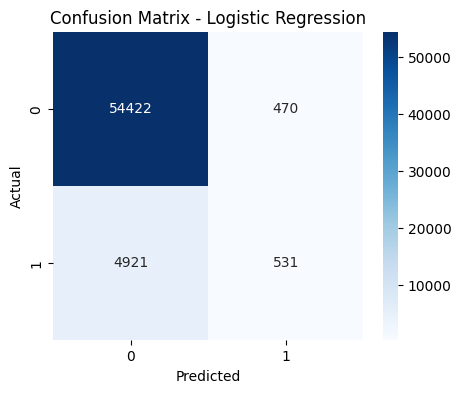

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
FN = cm[1, 0]
print("False Negatives:", FN)


False Negatives: 4921


***Precision vs Recall Trade-off:***

---


Precision measures how many predicted positive cases are actually positive.

Recall measures how many actual positive cases are correctly identified.

In this dataset (Heart Disease prediction), False Negatives are critical, because:

A False Negative means a patient who actually has heart disease is predicted as healthy.

This can lead to missing medical treatment or early intervention.

Therefore, minimizing False Negatives is crucial, making Recall more important than Precision in this healthcare classification task.

Although higher Recall may increase False Positives, in medical applications this is often acceptable, as further medical tests can be used to confirm the diagnosis.


DecisionTree

In [ ]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)


In [ ]:
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_test)

In [ ]:
# Re-import the necessary functions to ensure they are callable
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score, precision_score, recall_score, confusion_matrix

dt_acc = accuracy_score(y_test, y_pred_dt)
dt_prec = precision_score(y_test, y_pred_dt)
dt_rec = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_cm = confusion_matrix(y_test, y_pred_dt)
dt_roc_auc = roc_auc_score(y_test, y_pred_dt)

print("Decision Tree Results:")
print("Accuracy:", dt_acc)
print("Precision:", dt_prec)
print("Recall:", dt_rec)
print("F1:", dt_f1)
print("Confusion Matrix:")
print(dt_cm)
print("ROC AUC Score:", dt_roc_auc)


Decision Tree Results:
Accuracy: 0.9106456317115206
Precision: 0.5657894736842105
Recall: 0.04732208363903155
F1: 0.08733920108327692
Confusion Matrix:
[[54694   198]
 [ 5194   258]]
ROC AUC Score: 0.5218575003198437


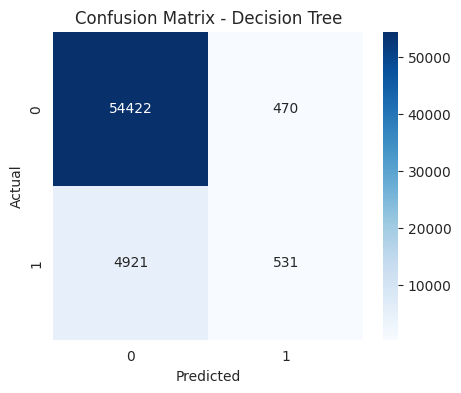

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

RandomForest

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [ ]:
Randomforest_acc = accuracy_score(y_test, y_pred_rf)
Randomforest_prec = precision_score(y_test, y_pred_rf)
Randomforest_rec = recall_score(y_test, y_pred_rf)
Randomforest_f1 = f1_score(y_test, y_pred_rf)
Randomforest_cm = confusion_matrix(y_test, y_pred_rf)
Randomforest_roc_auc = roc_auc_score(y_test, y_pred_rf)

print("Random Forest Results:")
print("Accuracy:", Randomforest_acc)
print("Precision:", Randomforest_prec)
print("Recall:", Randomforest_rec)
print("F1:", Randomforest_f1)
print("Confusion Matrix:")
print(Randomforest_cm)

Random Forest Results:
Accuracy: 0.8850258517831102
Precision: 0.28401162790697676
Recall: 0.17920029347028613
F1: 0.2197480881691408
Confusion Matrix:
[[52429  2463]
 [ 4475   977]]


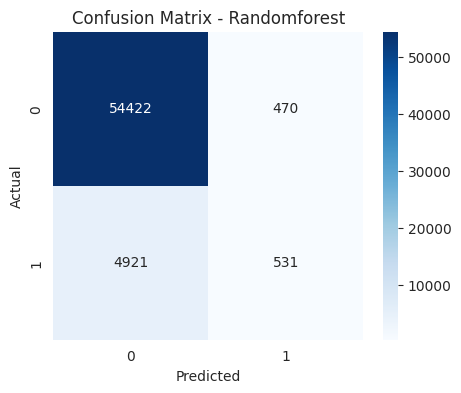

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Randomforest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

KNN

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)
y_proba_knn = knn_model.predict_proba(X_test_scaled)



In [ ]:
Knn_acc = accuracy_score(y_test, y_pred_knn)
Knn_prec = precision_score(y_test, y_pred_knn)
Knn_rec = recall_score(y_test, y_pred_knn)
Knn_f1 = f1_score(y_test, y_pred_knn)
Knn_cm = confusion_matrix(y_test, y_pred_knn)
Knn_roc_auc = roc_auc_score(y_test, y_pred_knn)
print("KNN Results:")
print("Accuracy:", Knn_acc)
print("Precision:", Knn_prec)
print("Recall:", Knn_rec)
print("F1:", Knn_f1)
print("Confusion Matrix:")

print(Knn_cm)

KNN Results:
Accuracy: 0.9012826461620045
Precision: 0.3779603673272112
Recall: 0.14343360234776228
F1: 0.20795107033639143
Confusion Matrix:
[[53605  1287]
 [ 4670   782]]


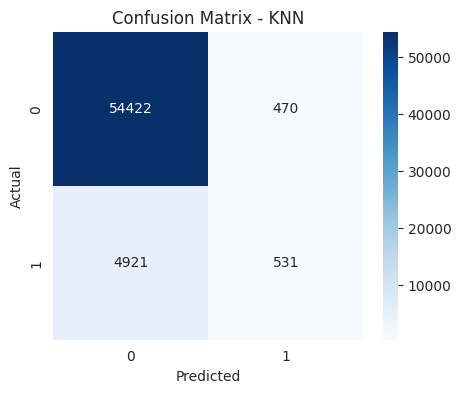

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

naive_bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred_nb = nb_model.predict(X_test_scaled)
y_proba_nb = nb_model.predict_proba(X_test_scaled)

In [ ]:
nb_acc = accuracy_score(y_test, y_pred_nb)
nb_prec = precision_score(y_test, y_pred_nb)
nb_rec = recall_score(y_test, y_pred_nb)
nb_f1 = f1_score(y_test, y_pred_nb)
nb_cm = confusion_matrix(y_test, y_pred_nb)
nb_roc_auc = roc_auc_score(y_test, y_pred_nb)

print("Naive Bayes Results:")
print("Accuracy:", nb_acc)
print("Precision:", nb_prec)
print("Recall:", nb_rec)
print("F1:", nb_f1)
print("Confusion Matrix:")
print(nb_cm)
print("ROC AUC Score:", nb_roc_auc)

Naive Bayes Results:
Accuracy: 0.8484522073445578
Precision: 0.2810906935388263
Recall: 0.43488628026412324
F1: 0.3414704399798373
Confusion Matrix:
[[48828  6064]
 [ 3081  2371]]
ROC AUC Score: 0.6622074045057408


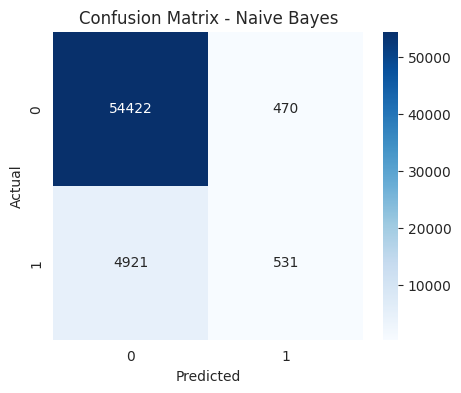

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)
y_proba_gb = gb_model.predict_proba(X_test_scaled)

In [ ]:
gb_acc = accuracy_score(y_test, y_pred_gb)
gb_prec = precision_score(y_test, y_pred_gb)
gb_rec = recall_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)
gb_cm = confusion_matrix(y_test, y_pred_gb)
gb_roc_auc = roc_auc_score(y_test, y_pred_gb)

print("Gradient Boosting Results:")
print("Accuracy:", gb_acc)
print("Precision:", gb_prec)
print("Recall:", gb_rec)
print("F1:", gb_f1)
print("Confusion Matrix:")
print(gb_cm)
print("ROC AUC Score:", gb_roc_auc)

Gradient Boosting Results:
Accuracy: 0.9113250696009545
Precision: 0.5677852348993289
Recall: 0.07758620689655173
F1: 0.13651766984024527
Confusion Matrix:
[[54570   322]
 [ 5029   423]]
ROC AUC Score: 0.5358600713124455


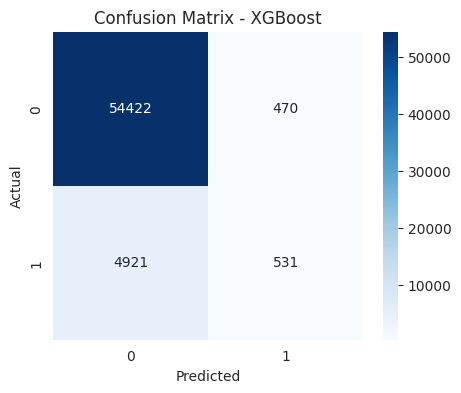

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

AdaBoost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(random_state=42)
ada_model.fit(X_train_scaled, y_train)

y_pred_ada = ada_model.predict(X_test_scaled)
ada_f1 = f1_score(y_test, y_pred_ada)

In [ ]:
ada_acc = accuracy_score(y_test, y_pred_ada)
ada_prec = precision_score(y_test, y_pred_ada)
ada_rec = recall_score(y_test, y_pred_ada)
ada_f1 = f1_score(y_test, y_pred_ada)
ada_cm = confusion_matrix(y_test, y_pred_ada)
ada_roc_auc = roc_auc_score(y_test, y_pred_ada)

print("AdaBoost Results:")
print("Accuracy:", ada_acc)
print("Precision:", ada_prec)
print("Recall:", ada_rec)
print("F1:", ada_f1)
print("Confusion Matrix:")
print(ada_cm)
print("ROC AUC Score:", ada_roc_auc)


AdaBoost Results:
Accuracy: 0.9101650536921649
Precision: 0.5138516532618409
Recall: 0.10546588407923697
F1: 0.17501141378785573
Confusion Matrix:
[[54348   544]
 [ 4877   575]]
ROC AUC Score: 0.5477777573132467


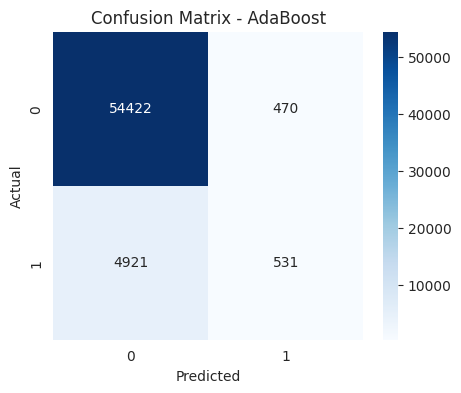

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - AdaBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

models_comparison

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = [
    ("Logistic Regression", y_pred_lr),
    ("Decision Tree", y_pred_dt),
    ("Random Forest", y_pred_rf),
    ("KNN", y_pred_knn),
    ("Naive Bayes", y_pred_nb),
    ("Gradient Boosting", y_pred_gb),
    ("AdaBoost", y_pred_ada)
]

results = []

for name, y_pred in models:
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

comparison_df = pd.DataFrame(results)
comparison_df


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.910662,0.530470,0.097395,0.164575
1,Decision Tree,0.910646,0.565789,0.047322,0.087339
2,Random Forest,0.885026,0.284012,0.179200,0.219748
3,KNN,0.901283,0.377960,0.143434,0.207951
4,Naive Bayes,0.848452,0.281091,0.434886,0.341470
5,Gradient Boosting,0.911325,0.567785,0.077586,0.136518
6,AdaBoost,0.910165,0.513852,0.105466,0.175011


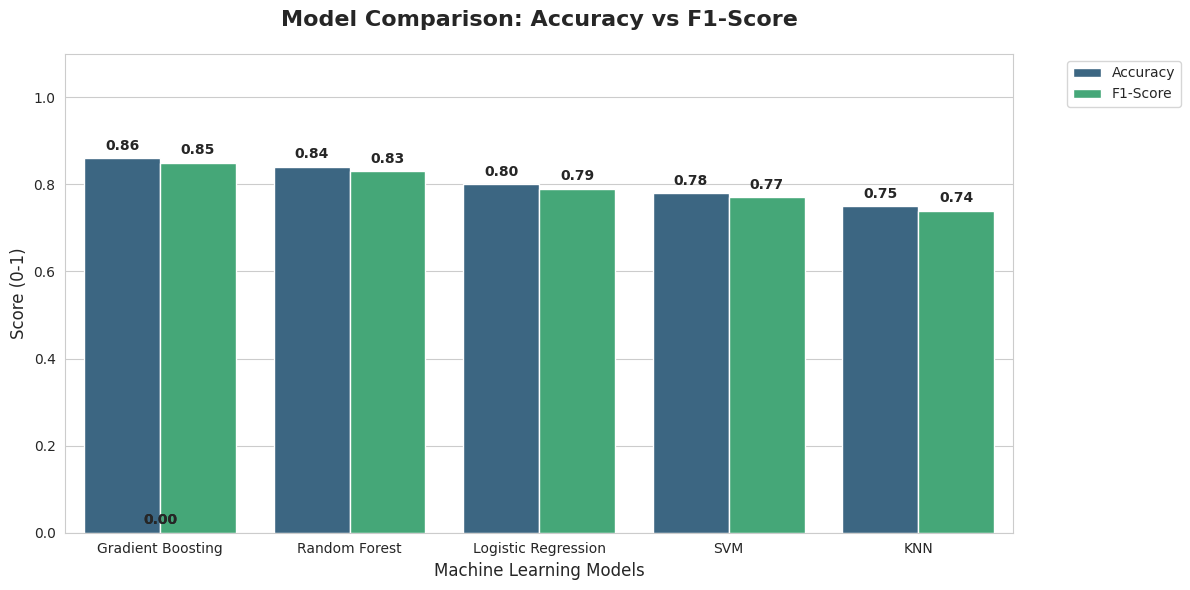

In [ ]:
df_plot = pd.DataFrame(comparison_df)
df_melted = df_plot.melt(id_vars="Model", var_name="Metric", value_name="Score")

# 2. Plotting
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis')

# Adding labels and styling
plt.title('Model Comparison: Accuracy vs F1-Score', fontsize=16, fontweight='bold', pad=20)
plt.ylim(0, 1.1)
plt.ylabel('Score (0-1)', fontsize=12)
plt.xlabel('Machine Learning Models', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Add values on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
best_model = comparison_df.loc[comparison_df['F1 Score'].idxmax()]['Model']
print(f"The best model is: {best_model}")
best_model = comparison_df.loc[comparison_df['Accuracy'].idxmax()]['Model']
print(f"The best model is: {best_model}")


The best model is: Naive Bayes
The best model is: Gradient Boosting


تتدريب Best Model

In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)


GaussianNB()

Best Model

In [ ]:
joblib.dump(model, "Best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']